Business Problem:
A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delievery, for products like sporting goods. The company is facing inconsistent delievery performance where actual shipping times often deviate from scheduled timelines, leading to late delieveries and unpredictable order profitability.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df=pd.read_csv(r'C:\Supply chain analysis\Data\DataCoSupplyChainDataset.csv', encoding='latin-1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

Exploratory data analysis 


In [4]:
print('rows, columns:', df.shape)
print('\nColumns:\n')
print(df.columns.tolist())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n') 
print(df.isnull().sum().sort_values(ascending=False).head(10))
print('\nDuplicates:', df.duplicated().sum())

#Here we are seeing the columns with the missing values, data types and duplicates in the dataset. 


rows, columns: (180519, 53)

Columns:

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Pr

In [5]:
#Here we drop the columns which is not necessary for our analysis 

columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',  
    'Product Status',     
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
    
]

df.drop(columns=columns_to_drop, inplace=True)

df=df[df['Delivery Status'] != 'Shipping cancelled']

#standard date conversion
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')


# After checking the data , let's check the overview
print('rows, columns:', df.shape)
print('\nColumns:\n')
print(df.columns.tolist())
print('\nData types:\n', df.dtypes) 
print('\nMissing values:\n')
print(df.isnull().sum().sort_values(ascending=False).head(10))


rows, columns: (180519, 20)

Columns:

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']

Data types:
 Type                                     object
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Sales per customer                      float64
Delivery Status                          object
Late_delivery_risk                        int64
Category Name                            object
Customer Country                         object
Customer Segment                         object
Department Name                          object
order date (DateOrders)          datetime64[ns]
Order Ite

In [6]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col}: value counts')
        print(df[col].value_counts())


Type: value counts
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real): value counts
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled): value counts
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status: value counts
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk: value counts
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country: value counts
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment: value counts
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status: value 

In [7]:
#Calucate order processing time
df['order processing time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay']=df['order processing time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month']=df['order date (DateOrders)'].dt.month
df['order_day']=df['order date (DateOrders)'].dt.day_name()
df['order_hour']=df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),order processing time,Delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,183.107609,0.548291,2016-06-12 17:47:04.669868544,0.120647,203.772096,21.974989,141.232550,2016-06-16 05:45:23.202433024,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 13:49:00,0.080000,119.980003,7.000000,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 13:06:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-03-01 08:42:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,120.043670,0.497664,NaN,0.466796,132.273077,104.433526,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [8]:
#From here we come to know  how much delay happened in numbers according to which we search for the factors 
#responsible for the delay.

df['Is_Delayed'].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [9]:
df['Profitability_flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profitable',  np.where(df['Order Profit Per Order'] < 0, 'Not Profitable', 'Break Even'))
df['Profitability_flag'].value_counts(normalize=True)

Profitability_flag
Profitable        0.806331
Not Profitable    0.187149
Break Even        0.006520
Name: proportion, dtype: float64

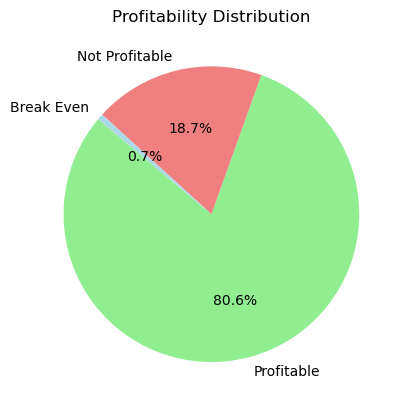

In [10]:
#Here we draw the bar chart to show the distribution of profitability flag for the orders in the dataset.

Profit_counts=df['Profitability_flag'].value_counts(normalize=True)*100
Profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'lightcoral', 'lightblue'], startangle=140)
plt.ylabel('')
plt.title('Profitability Distribution')
plt.show()




In [11]:
def format_function(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K'
    else:
        return f'{int(value): .0f}'
    

delayed_counts=df[df['Delay']>0]
metrics={}
metrics['Total Orders']=len(df)
metrics['Delayed Orders']=len(delayed_counts)
metrics['90% Delay Percentile']=delayed_counts['Delay'].quantile(0.9)
metrics['On time delivery rate']=(1-float(metrics['Delayed Orders'])/metrics['Total Orders'])*100
metrics['Late Delivery Rate']=float(metrics['Delayed Orders'])/metrics['Total Orders']*100
metrics['Total Profit']= format_function(df.loc[df['Order Profit Per Order'] >0, 'Order Profit Per Order'].sum())
metrics['Total loss']= format_function(df.loc[df['Delay'] >0, 'Order Profit Per Order'].sum())


print("\n...............................Key Metrics:................................\n")
for key, value in metrics.items():
    if isinstance(value, float):
        print(f'{key}: {value:.2f}')
    else:        print(f'{key}: {value}')








...............................Key Metrics:................................

Total Orders: 180519
Delayed Orders: 98743
90% Delay Percentile: 3.00
On time delivery rate: 45.30
Late Delivery Rate: 54.70
Total Profit: 7.9M
Total loss: 2.1M


Profitability vs Delivery time analysis 

In [12]:
profit_metrics= (  
        df.groupby('Delay')['Order Profit Per Order'].agg(
            mean_profit='mean',
            total_profit='sum',
            orders_count='count'


        ).reset_index()

)

In [13]:
profit_metrics

,Delay,mean_profit,total_profit,orders_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [14]:
delay_distribution=(df['Delay'].value_counts(normalize=True).sort_index()*100).reset_index()
delay_distribution


,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,orders_count
0,-2,23.4,507494.2,21666
1,-1,21.5,466918.8,21700
2,0,22.0,846742.9,38410
3,1,22.2,1244410.9,55990
4,2,21.2,610149.5,28718
5,3,19.9,140624.8,7052
6,4,21.6,150561.9,6983



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


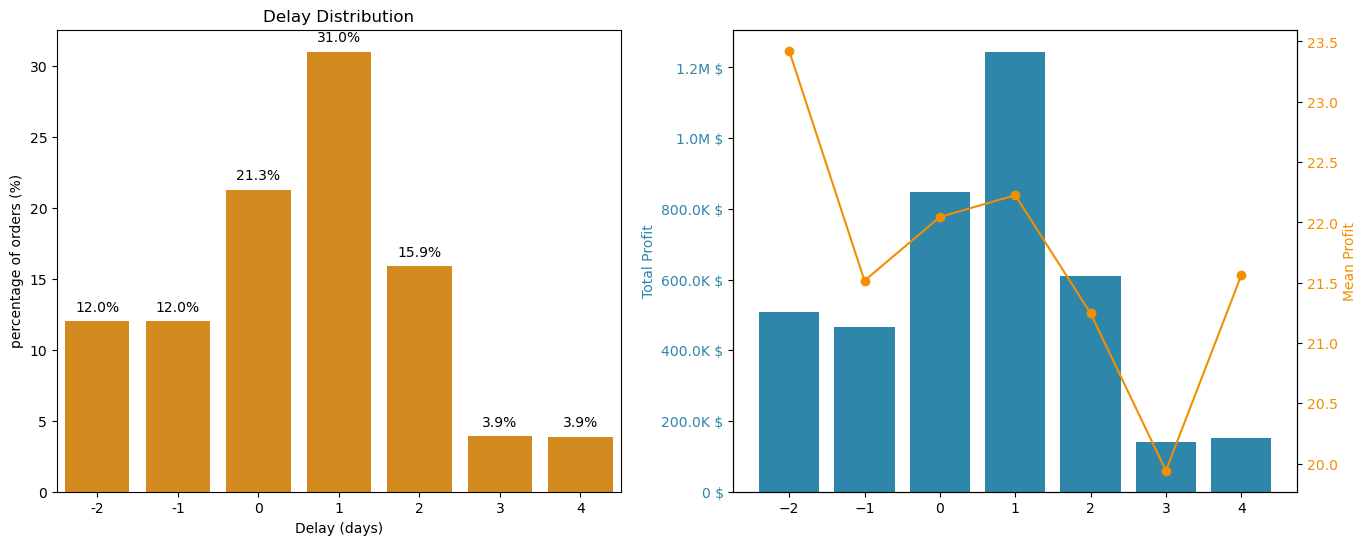

In [16]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color='#F18F01', ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel('Total Profit', color='#2E86AB')
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color='#2E86AB', label='Total Profit')
ax2.tick_params(axis='y', labelcolor='#2E86AB')

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color='#F18F01')
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color='#F18F01')
ax3.tick_params(axis='y', labelcolor='#F18F01')

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

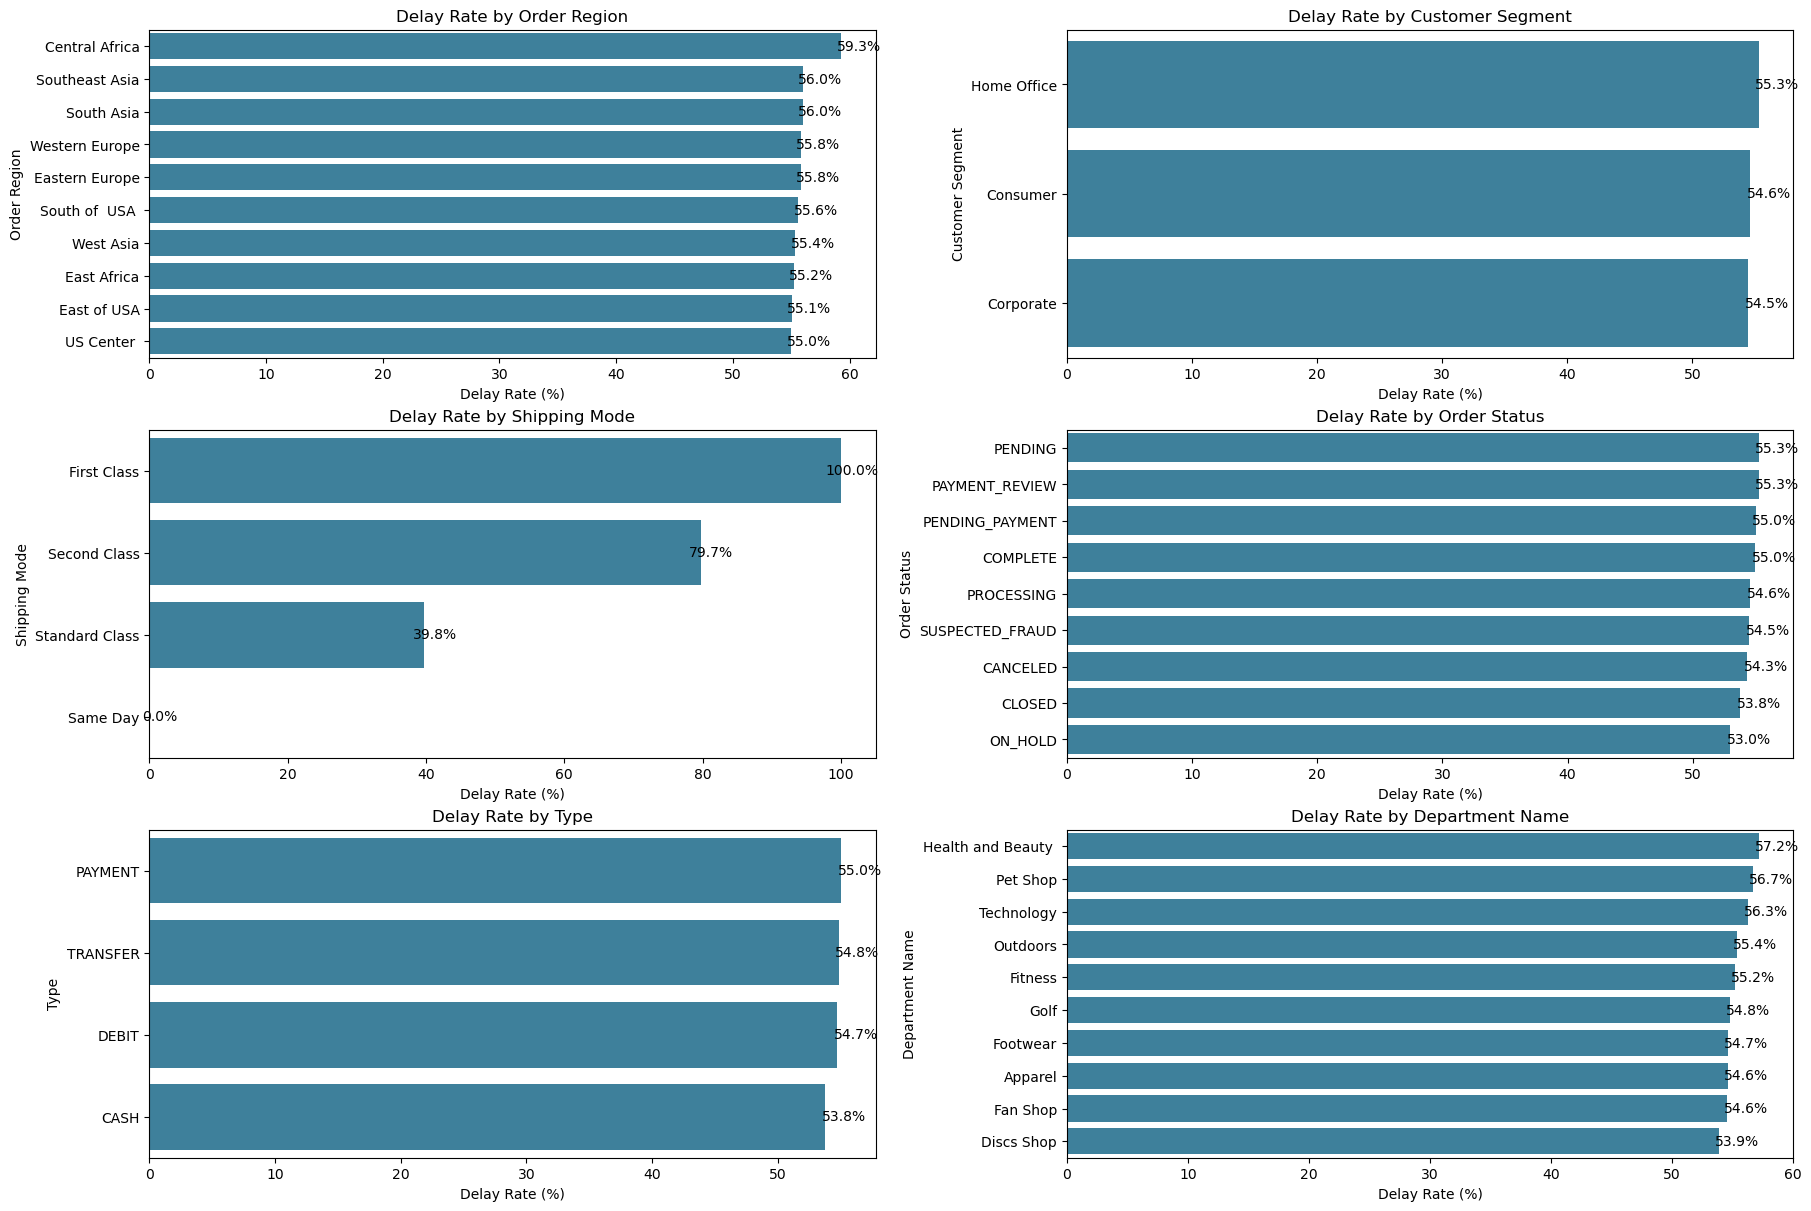

In [27]:
# Bottleneck detection
def bottlecneck_detection(category):    
    category_metrics = df.groupby(category).agg(
            total_orders=('Delay', 'count'),
            delayed_orders=('Is_Delayed', 'sum')
        ).reset_index()
    # Rename the groupby column to a consistent name
    category_metrics.rename(columns={category: 'category_name'}, inplace=True)
    category_metrics['delay_rate']=(category_metrics['delayed_orders'] / category_metrics['total_orders'])*100
    category_metrics = category_metrics.sort_values('delay_rate', ascending=False).head(10)
    return category_metrics

categories=['Order Region','Customer Segment','Shipping Mode','Order Status','Type','Department Name']

fig, axes = plt.subplots( 3,2, figsize=(18, 12), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    category_metrics = bottlecneck_detection(category)
    sns.barplot(data=category_metrics, x='delay_rate', y='category_name', ax=ax, color='#2E86AB' ) 
    ax.set_title(f'Delay Rate by {category}')
    ax.set_xlabel('Delay Rate (%)')
    ax.set_ylabel(category)
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width + 1.5, bar.get_y() + bar.get_height()/2 , f'{width:.1f}%', ha='center', va='center')

plt.show()

    

Root Cause analysis 
Here we will take regionwise to see the problems which causing the delay in particular region

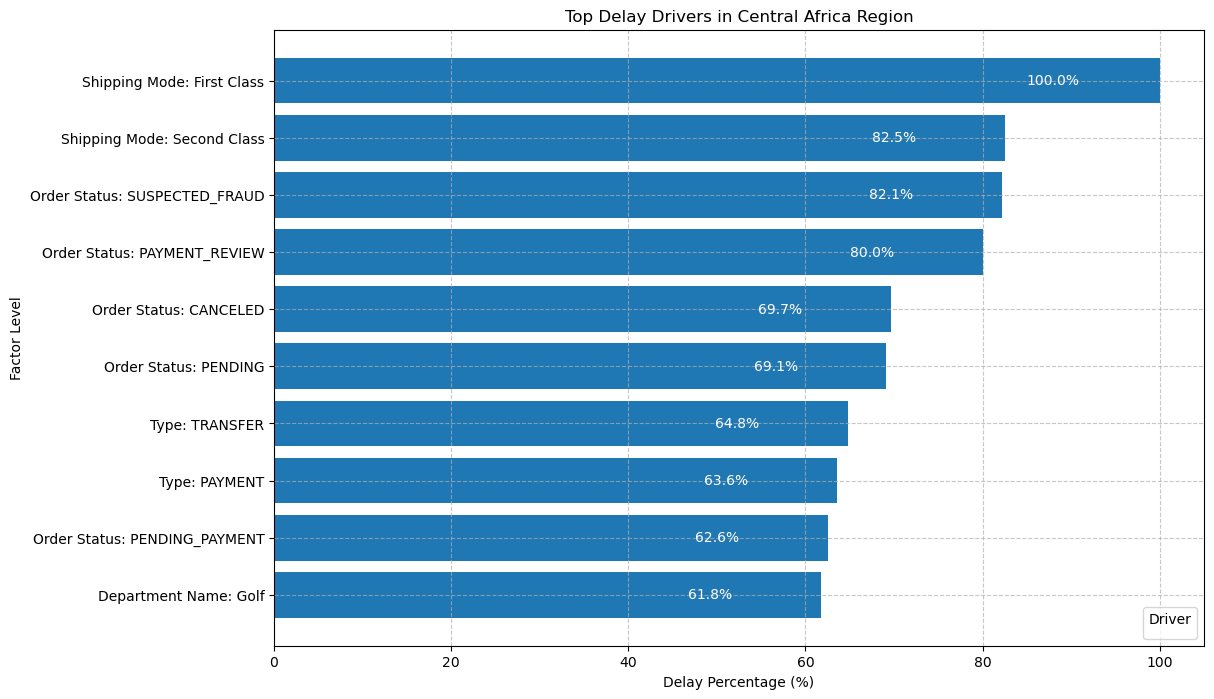

In [28]:


def analyze_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers=['Customer Segment','Shipping Mode','Order Status','Type','Department Name']

    all_metrics = []
    for factor in drivers:
        temp = (df_region.groupby(factor).agg
        (
            total_orders=('Delay', 'count'),
            delayed_orders=('Is_Delayed', 'sum'),
            avg_delay=('Delay', 'mean') 
        ).reset_index()
        )
        
        temp['delay_percentage'] = (temp['delayed_orders'] / temp['total_orders']) * 100
        temp['driver'] = factor
        temp['Factor_level']= factor + ': ' + temp[factor].astype(str)
        all_metrics.append(temp[['Factor_level', 'delay_percentage', 'avg_delay', 'driver','total_orders','avg_delay']])

    final_df = pd.concat(all_metrics, ignore_index=True)

    #Top 10 drivers
    top_factors = final_df.sort_values('delay_percentage', ascending=False).head(10)
    plt.figure(figsize=(12, 8))
    bar= plt.barh(top_factors['Factor_level'], top_factors['delay_percentage'] )
    # sns.barplot(data=top_factors, x='delay_percentage', y='Factor_level', hue='driver', dodge=False, palette='viridis')
    plt.title(f'Top Delay Drivers in {region} Region')
    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Factor Level')
    plt.legend(title='Driver')
    plt.grid(True,linestyle='--', alpha=0.7)
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest delay percentage on top
    for i, (idx, row) in enumerate(top_factors.iterrows()):
        width = row['delay_percentage']
        plt.text(width - 15, i, f"{row['delay_percentage']:.1f}%", fontsize=10, va='center', color='white')
    plt.show()

analyze_region('Central Africa')    
        


Time based analysis 

In [31]:
df.columns


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'order processing time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour', 'Profitability_flag'],
      dtype='object')

In [30]:
delay_by_month = (df.groupby('order_month')
['Is_Delayed'].mean().reset_index())

delay_by_month['delay_percentage']=delay_by_month['Is_Delayed']*100

delay_by_day=(df.groupby('order_day')
              ['Is_Delayed'].mean().reset_index())

delay_by_day['delay_percentage']=delay_by_day['Is_Delayed']*100

delay_by_hour=(df.groupby('order_hour')
              ['Is_Delayed'].mean().reset_index())

delay_by_hour['delay_percentage']=delay_by_hour['Is_Delayed']*100


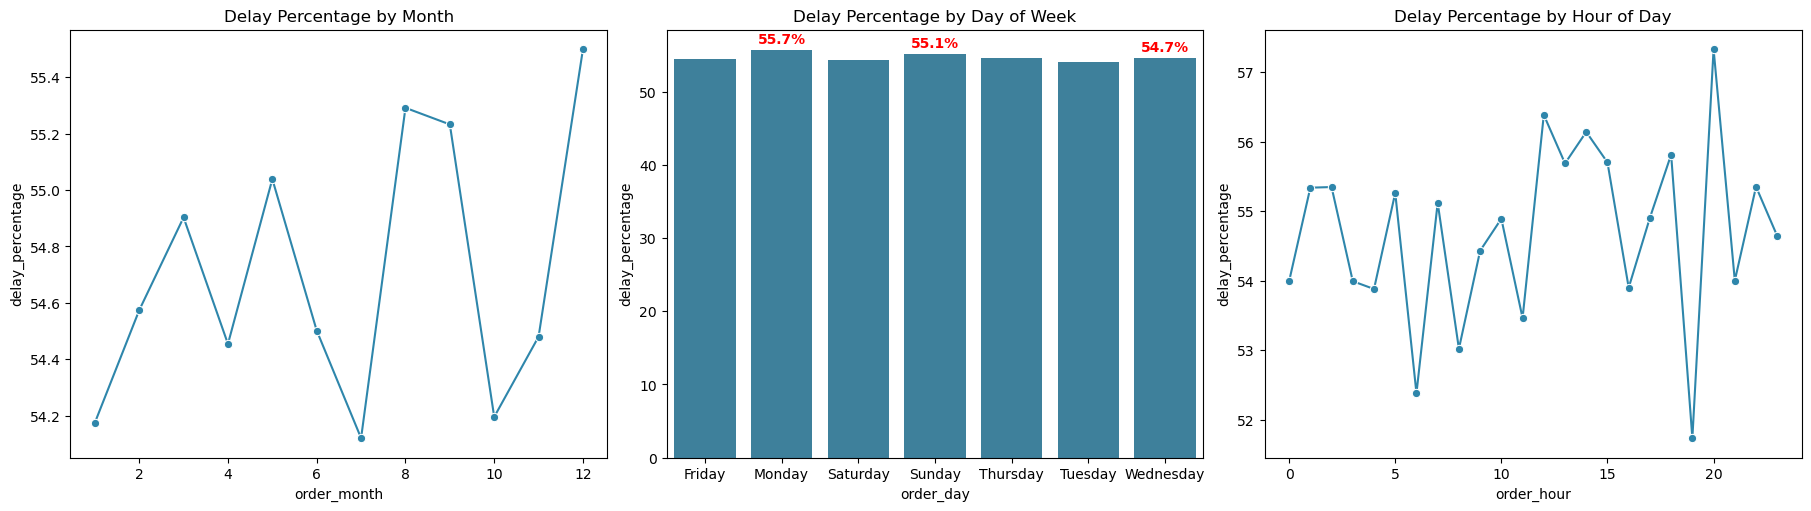

In [34]:
# Drawing bar charts for delay by month, day and hour
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
sns.lineplot(x='order_month', y='delay_percentage', data=delay_by_month, ax=axes[0], color='#2E86AB',marker='o')
axes[0].set_title('Delay Percentage by Month')

#Top 3 delay months
for bar in axes[0].patches:
    height = bar.get_height()
    if height >= delay_by_month['delay_percentage'].nlargest(3).iloc[-1]:  # Check if it's in the top 3
        axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', color='red', fontweight='bold')


# Top 3 delay days
sns.barplot(x='order_day', y='delay_percentage', data=delay_by_day, ax=axes[1], color='#2E86AB')
axes[1].set_title('Delay Percentage by Day of Week')
for bar in axes[1].patches:
    height = bar.get_height()
    if height >= delay_by_day['delay_percentage'].nlargest(3).iloc[-1]:  # Check if it's in the top 3
        axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', color='red', fontweight='bold')

# Top 3 delay hours
sns.lineplot(x='order_hour', y='delay_percentage', data=delay_by_hour, ax=axes[2], color='#2E86AB',marker='o')
axes[2].set_title('Delay Percentage by Hour of Day')
for bar in axes[2].patches:
    height = bar.get_height()
    if height >= delay_by_hour['delay_percentage'].nlargest(3).iloc[-1]:  # Check if it's in the top 3
        axes[2].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', color='red', fontweight='bold')


plt.show()


Machine learning models

In [35]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score,accuracy_score
from collections import Counter
from imblearn.over_sampling import SMOTE

In [36]:
X=df[['Type','Days for shipment (scheduled)','Category Name','Customer Segment','Shipping Mode','Order Status','Department Name','Order Region','order_month','order_day','order_hour']]
y=df['Late_delivery_risk']

In [37]:
cat_col=X.select_dtypes(include=['object','category']).columns.tolist()
print('Categorical columns:', cat_col)

#Frequency encoding for categorical variables
for col in cat_col:
    freq_encoding=X[col].value_counts(normalize=True)
    X[f'{col}_freq']=X[col].map(freq_encoding)

#keep numeric columns and encoded categorical columns,drop original categorical columns
X_encoded=X.drop(columns=cat_col)
print('Encoded feature columns:', X_encoded.shape)

#Use encoded features for modeling
X=X_encoded
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Department Name', 'Order Region', 'order_day']
Encoded feature columns: (180519, 11)


In [38]:
y.value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [39]:
print('Before SMOTE:', Counter(y_train))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('After SMOTE:', Counter(y_train_smote))


Before SMOTE: Counter({1: 79181, 0: 65234})
After SMOTE: Counter({1: 79181, 0: 79181})


In [40]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

In [41]:
#Fit Random Forest Classifier
rf_model = RandomForestClassifier( random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
y_pred = rf_model.predict(X_test)
evaluate_model(rf_model, X_test, y_test)


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79     16308
           1       0.85      0.78      0.82     19796

    accuracy                           0.81     36104
   macro avg       0.80      0.81      0.80     36104
weighted avg       0.81      0.81      0.81     36104

Precision: 0.8484600262123198
Recall: 0.7848555263689634
Accuracy: 0.8051739419454909
